In [34]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, log_loss, brier_score_loss
)
from load_data import load_modality_data
from modality_eval import evaluate_modality
from augmented_modality_eval import aug_evaluate_modality
import numpy as np
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, 
                           matthews_corrcoef, confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from diagnostics import plot_diagnostics

In [35]:
base_dir = 'h5_sep'
subjects = [2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28]

## Baseline

In [57]:
font = '20F/S'
condition = 'Control' #put 'Parity' for parity, 'Control' for control

### Cross-modality

#### Digits → Number Words

In [58]:
dig_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'cross', 'NumWo')

#### Number Words → Digits

In [59]:
words_to_dig = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'cross', 'Dig')

#### Plotting diagnostics


Digits→Words, same condition, same font Performance:
Accuracy: 0.504 (Chance: 0.5)
Balanced Accuracy: 0.504
ROC AUC: 0.507
Matthews CC: 0.008
Support: 3220 samples


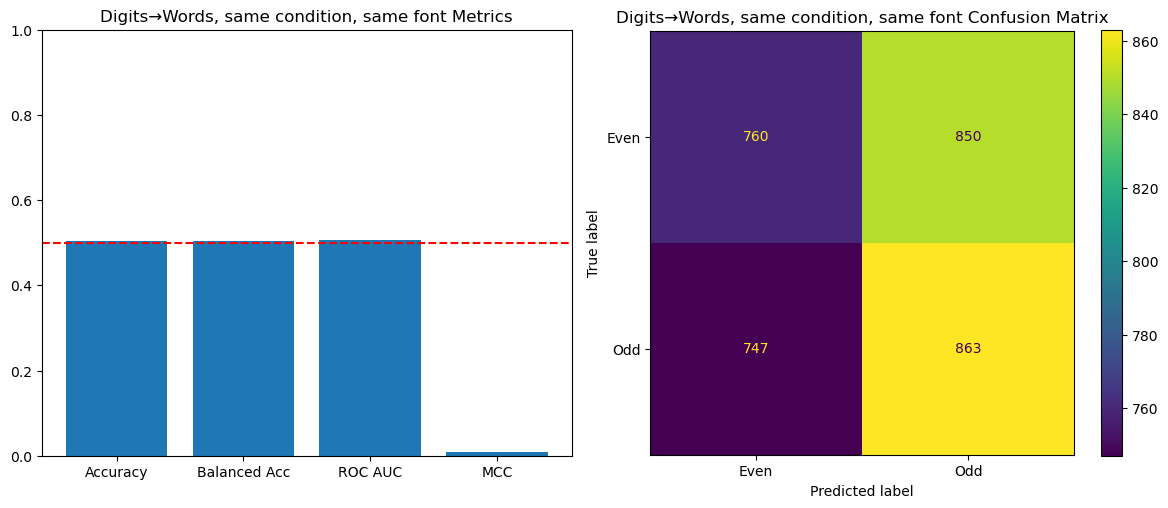

         feature  importance
5       contrast    0.117519
6  dissimilarity    0.102194
7    homogeneity    0.101482
2          alpha    0.100835
8         energy    0.099801

Words→Digits, same condition, same font Performance:
Accuracy: 0.506 (Chance: 0.5)
Balanced Accuracy: 0.506
ROC AUC: 0.506
Matthews CC: 0.011
Support: 3220 samples


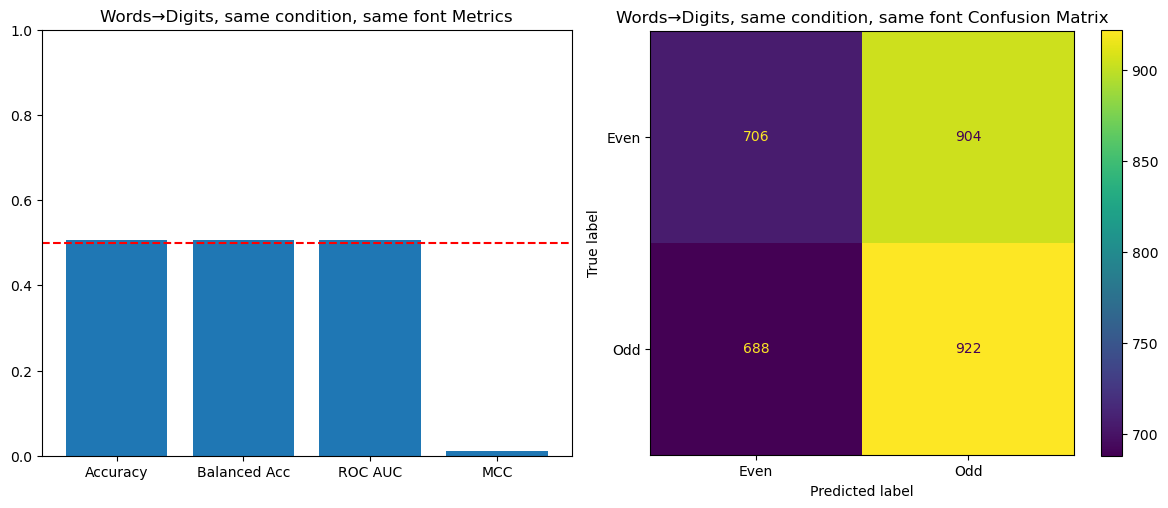

       feature  importance
8       energy    0.114988
9  correlation    0.103083
7  homogeneity    0.101397
2        alpha    0.100092
5     contrast    0.098998


In [60]:
for name, result in [('Digits→Words, same condition, same font', dig_to_words), 
                    ('Words→Digits, same condition, same font', words_to_dig)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

#### Null-model comparison

In [22]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality, font, condition)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

Dig null accuracy: 0.500
NumWo null accuracy: 0.500


### Within-modality

#### Digits

In [61]:
dig_results = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'within')

#### Number Words (Within Modality)

In [62]:
numwo_results = evaluate_modality(base_dir, subjects, 'NumWo', font, condition, 'within')

#### Plotting diagnostics


Digits, same condition, same font Performance:
Accuracy: 0.914 (Chance: 0.5)
Balanced Accuracy: 0.914
ROC AUC: 0.974
Matthews CC: 0.828
Support: 3220 samples


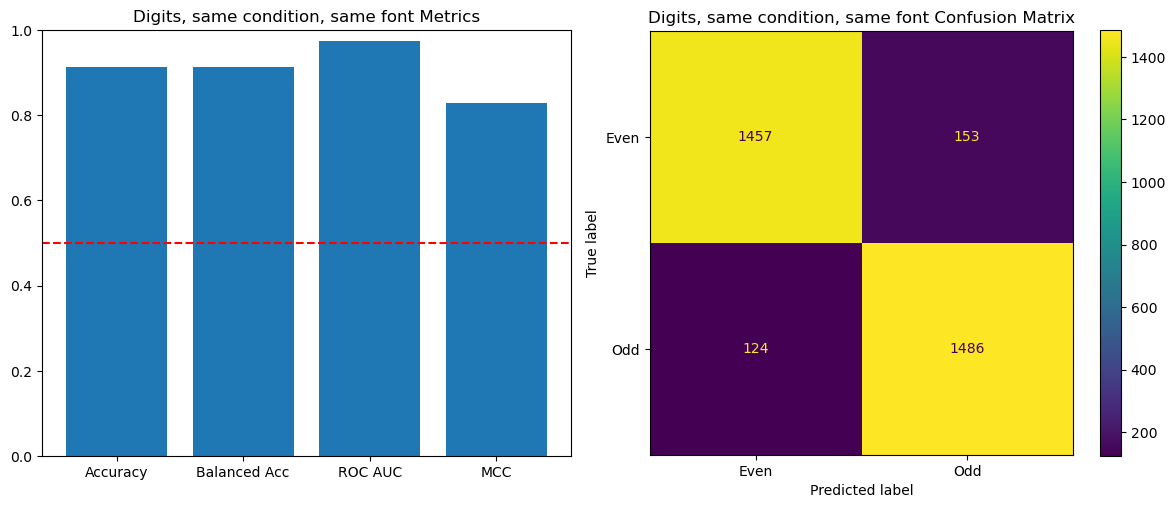

         feature  importance
5       contrast    0.117519
6  dissimilarity    0.102194
7    homogeneity    0.101482
2          alpha    0.100835
8         energy    0.099801

Number Words, same condition, same font Performance:
Accuracy: 0.950 (Chance: 0.5)
Balanced Accuracy: 0.950
ROC AUC: 0.991
Matthews CC: 0.899
Support: 3220 samples


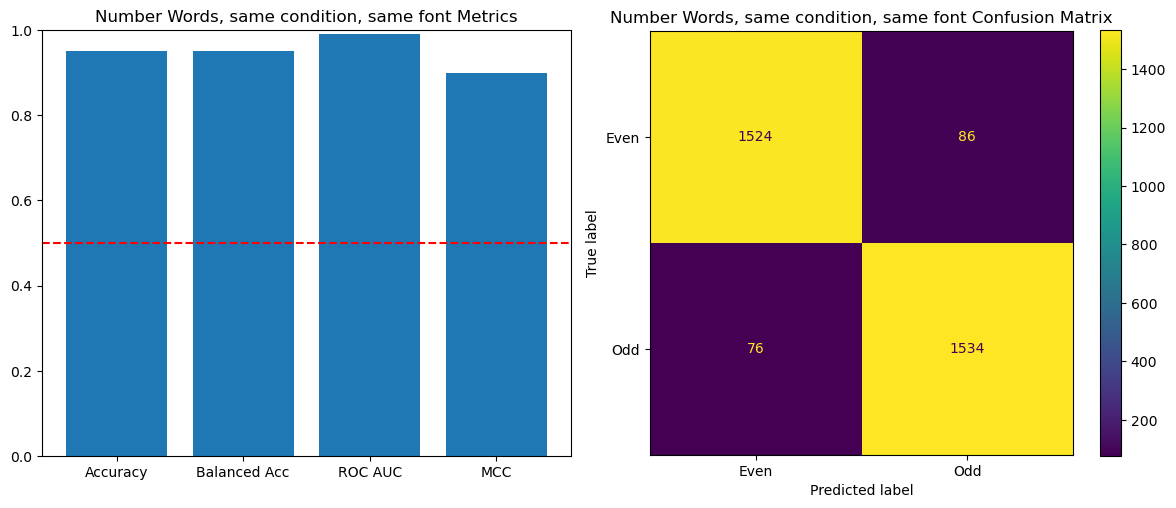

       feature  importance
8       energy    0.114988
9  correlation    0.103083
7  homogeneity    0.101397
2        alpha    0.100092
5     contrast    0.098998


In [63]:
for name, result in [('Digits, same condition, same font', dig_results), 
                    ('Number Words, same condition, same font', numwo_results)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

#### Null Model Comparison

In [ ]:
for modality in ['Dig', 'NumWo']:
    X, y, _ = load_modality_data(base_dir, subjects, modality, font, condition)
    if not X.empty:
        null_acc = max(y.mean(), 1 - y.mean()) 
        print(f"{modality} null accuracy: {null_acc:.3f}")

### Mixed modality

#### Mixed → Digits

In [64]:
mixed_to_digits = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'Dig')

#### Mixed → Number Words

In [65]:
mixed_to_words = evaluate_modality(base_dir, subjects, 'Dig', font, condition, 'mixed', 'NumWo')

#### Plotting diagnostics


Mixed→Digits, same condition, same font Performance:
Accuracy: 0.864 (Chance: 0.5)
Balanced Accuracy: 0.864
ROC AUC: 0.940
Matthews CC: 0.727
Support: 3220 samples


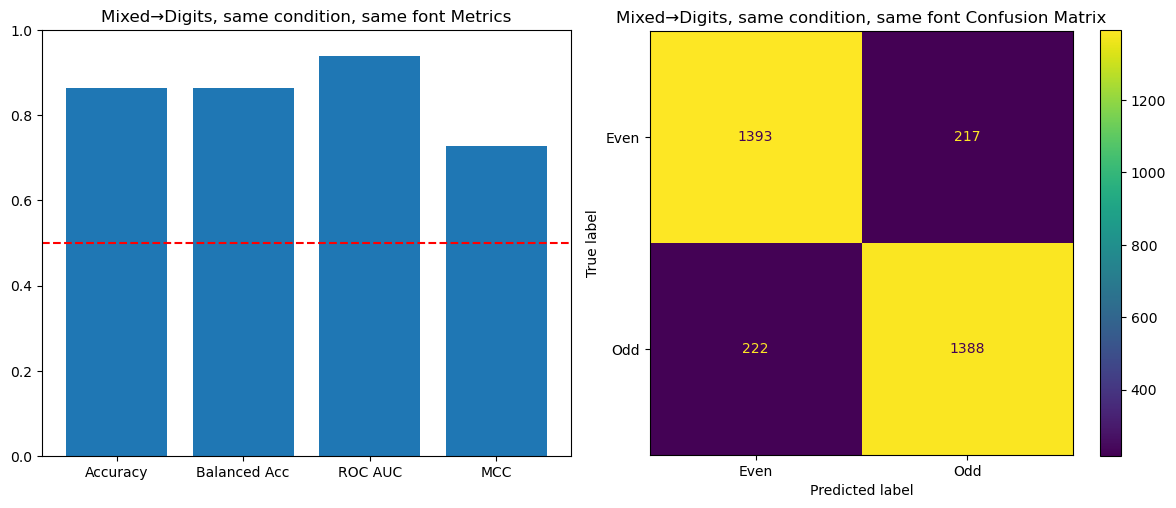

         feature  importance
6  dissimilarity    0.105191
8         energy    0.097503
1          theta    0.097360
5       contrast    0.097119
0          delta    0.092384

Mixed→Words, same condition, same font Performance:
Accuracy: 0.878 (Chance: 0.5)
Balanced Accuracy: 0.878
ROC AUC: 0.957
Matthews CC: 0.755
Support: 3220 samples


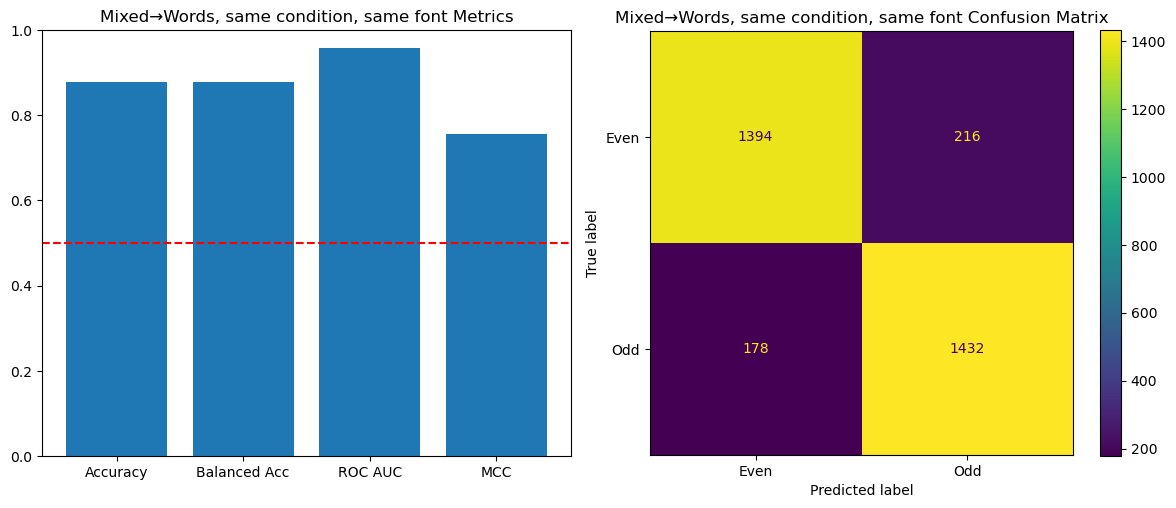

         feature  importance
6  dissimilarity    0.105191
8         energy    0.097503
1          theta    0.097360
5       contrast    0.097119
0          delta    0.092384


In [66]:
for name, result in [('Mixed→Digits, same condition, same font', mixed_to_digits), 
                    ('Mixed→Words, same condition, same font', mixed_to_words)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

## Augmented

In [179]:
modality = 'Dig'
mode = 'within'
test_mod=None #put None for within

### Font separation

In [124]:
condition = 'Parity'

In [125]:
f1_20s = aug_evaluate_modality(base_dir, subjects, modality, 
                     '1F', '20F/S', 
                     condition, mode=mode, test_mod=test_mod)

f1_20a = aug_evaluate_modality(base_dir, subjects, modality, 
                     '1F', '20F/A', 
                     condition, mode=mode, test_mod=test_mod)

f20a_20s = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/A', '20F/S', 
                     condition, mode=mode, test_mod=test_mod)

f20s_20a = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/S', '20F/A', 
                     condition, mode=mode, test_mod=test_mod)

f20a_1f = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/A', '1F', 
                     condition, mode=mode, test_mod=test_mod)

f20s_1f = aug_evaluate_modality(base_dir, subjects, modality, 
                     '20F/S', '1F', 
                     condition, mode=mode, test_mod=test_mod)


1F → 20F (S) across NumWo, Parity, mixed Performance:
Accuracy: 0.495 (Chance: 0.5)
Balanced Accuracy: 0.495
ROC AUC: 0.501
Matthews CC: -0.010
Support: 3220 samples


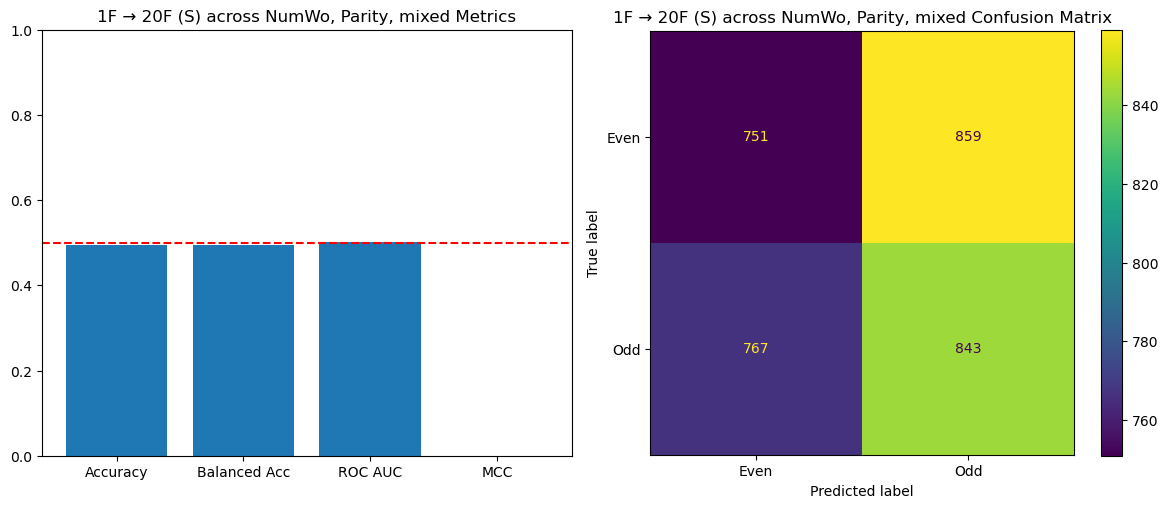

         feature  importance
8         energy    0.106417
7    homogeneity    0.104151
4          gamma    0.102940
6  dissimilarity    0.102667
1          theta    0.101291

1F → 20F (A) across NumWo, Parity, mixed Performance:
Accuracy: 0.495 (Chance: 0.5)
Balanced Accuracy: 0.495
ROC AUC: 0.504
Matthews CC: -0.009
Support: 3220 samples


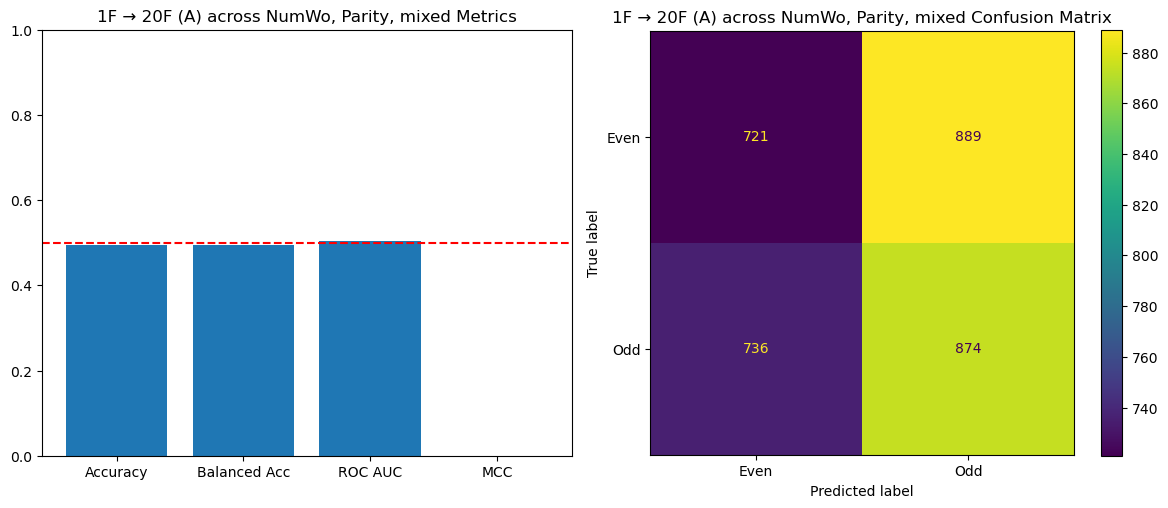

         feature  importance
8         energy    0.106417
7    homogeneity    0.104151
4          gamma    0.102940
6  dissimilarity    0.102667
1          theta    0.101291

20F (A) → 20F (S) across NumWo, Parity, mixed Performance:
Accuracy: 0.508 (Chance: 0.5)
Balanced Accuracy: 0.508
ROC AUC: 0.516
Matthews CC: 0.017
Support: 3220 samples


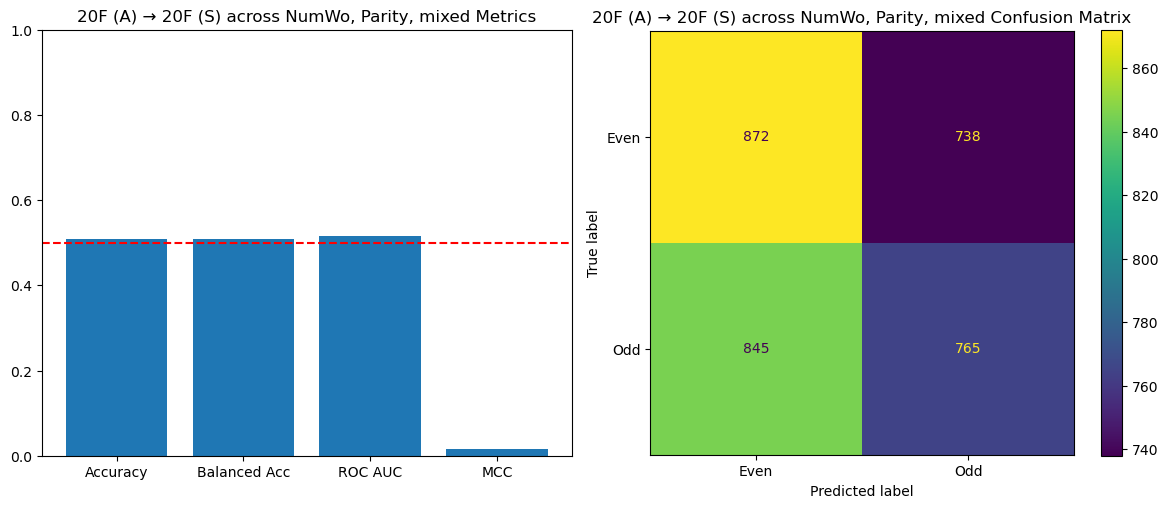

         feature  importance
0          delta    0.104960
3           beta    0.104253
6  dissimilarity    0.103026
1          theta    0.102429
9    correlation    0.101977

20F (S) → 20F (A) across NumWo, Parity, mixed Performance:
Accuracy: 0.505 (Chance: 0.5)
Balanced Accuracy: 0.505
ROC AUC: 0.495
Matthews CC: 0.009
Support: 3220 samples


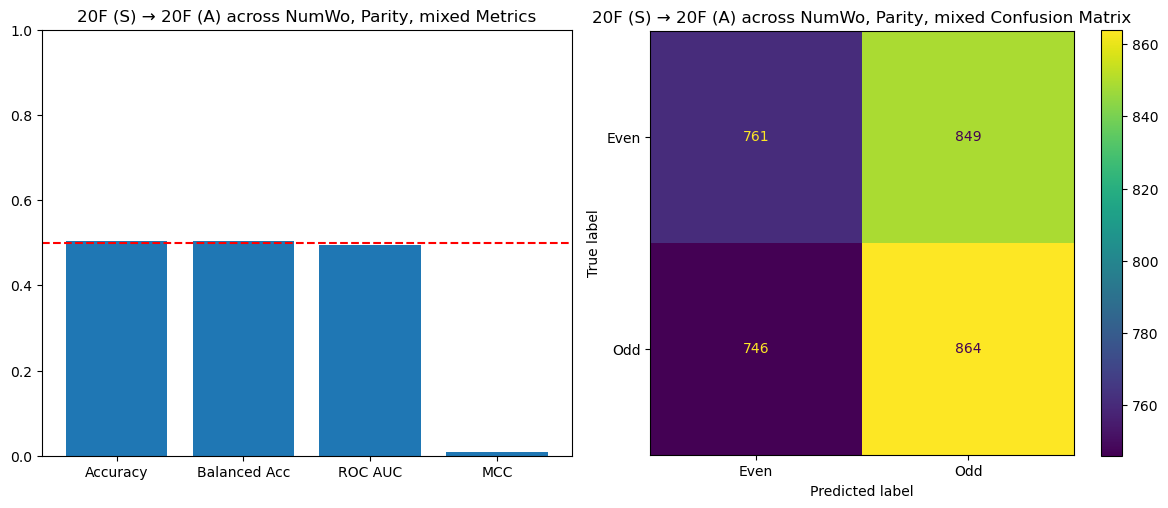

         feature  importance
6  dissimilarity    0.108450
7    homogeneity    0.100996
9    correlation    0.100823
4          gamma    0.100359
2          alpha    0.099172

20F (A) → 1F across NumWo, Parity, mixed Performance:
Accuracy: 0.489 (Chance: 0.5)
Balanced Accuracy: 0.489
ROC AUC: 0.487
Matthews CC: -0.022
Support: 3220 samples


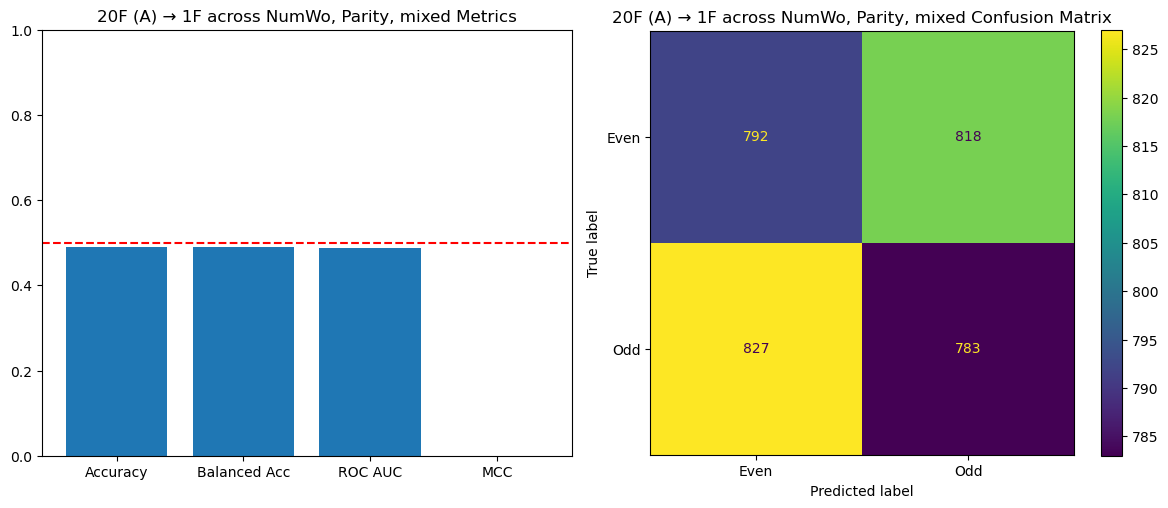

         feature  importance
0          delta    0.104960
3           beta    0.104253
6  dissimilarity    0.103026
1          theta    0.102429
9    correlation    0.101977

20F (S) → 1F across NumWo, Parity, mixed Performance:
Accuracy: 0.501 (Chance: 0.5)
Balanced Accuracy: 0.501
ROC AUC: 0.507
Matthews CC: 0.002
Support: 3220 samples


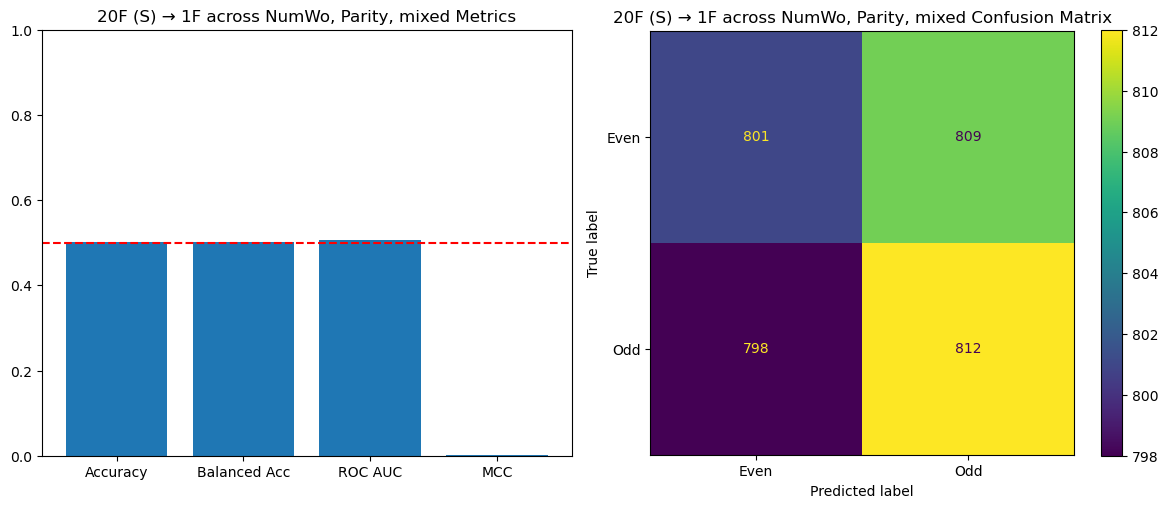

         feature  importance
6  dissimilarity    0.108450
7    homogeneity    0.100996
9    correlation    0.100823
4          gamma    0.100359
2          alpha    0.099172


In [126]:
for name, result in [(f'1F → 20F (S) across {modality}, {condition}, {mode}', f1_20s),
                     (f'1F → 20F (A) across {modality}, {condition}, {mode}', f1_20a),
                     (f'20F (A) → 20F (S) across {modality}, {condition}, {mode}', f20a_20s),
                     (f'20F (S) → 20F (A) across {modality}, {condition}, {mode}', f20s_20a),
                     (f'20F (A) → 1F across {modality}, {condition}, {mode}', f20a_1f),
                     (f'20F (S) → 1F across {modality}, {condition}, {mode}', f20s_1f)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")

### Condition separation

In [ ]:
font = '20F/A'

In [185]:
par_c1 = aug_evaluate_modality(base_dir, subjects, modality, 
                     font, condition_train='Parity', condition_test='Control',
                     mode=mode, test_mod=test_mod)

c1_par = aug_evaluate_modality(base_dir, subjects, modality, 
                     font, condition_train='Control', condition_test='Parity',
                     mode=mode, test_mod=test_mod)


Parity → Control across Dig, 20F/S, within Performance:
Accuracy: 0.499 (Chance: 0.5)
Balanced Accuracy: 0.499
ROC AUC: 0.500
Matthews CC: -0.001
Support: 3220 samples


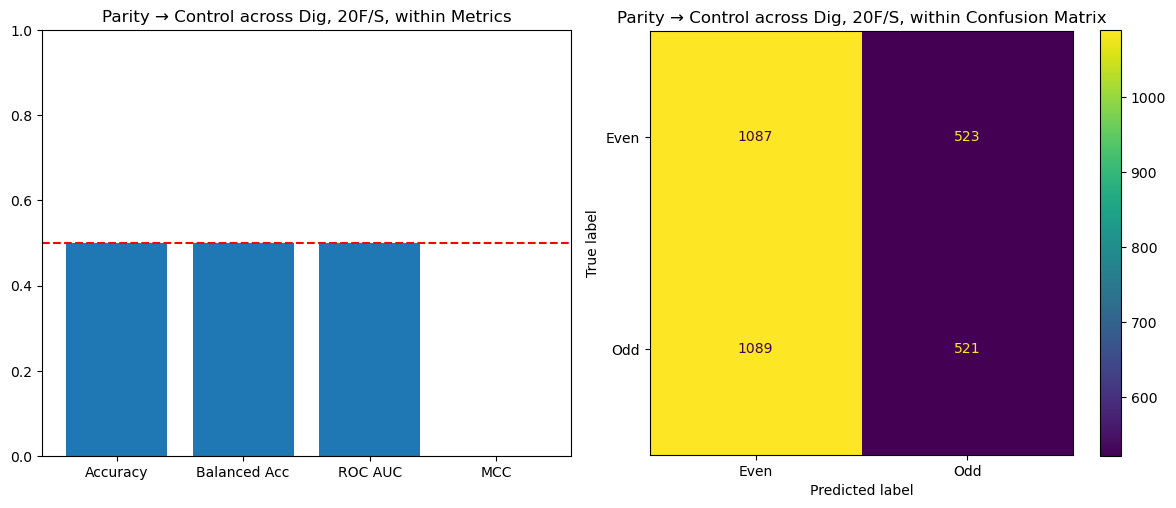

         feature  importance
6  dissimilarity    0.107236
8         energy    0.104386
7    homogeneity    0.102696
5       contrast    0.100669
9    correlation    0.099197

Control → Parity across Dig, 20F/S, within Performance:
Accuracy: 0.503 (Chance: 0.5)
Balanced Accuracy: 0.503
ROC AUC: 0.505
Matthews CC: 0.006
Support: 3220 samples


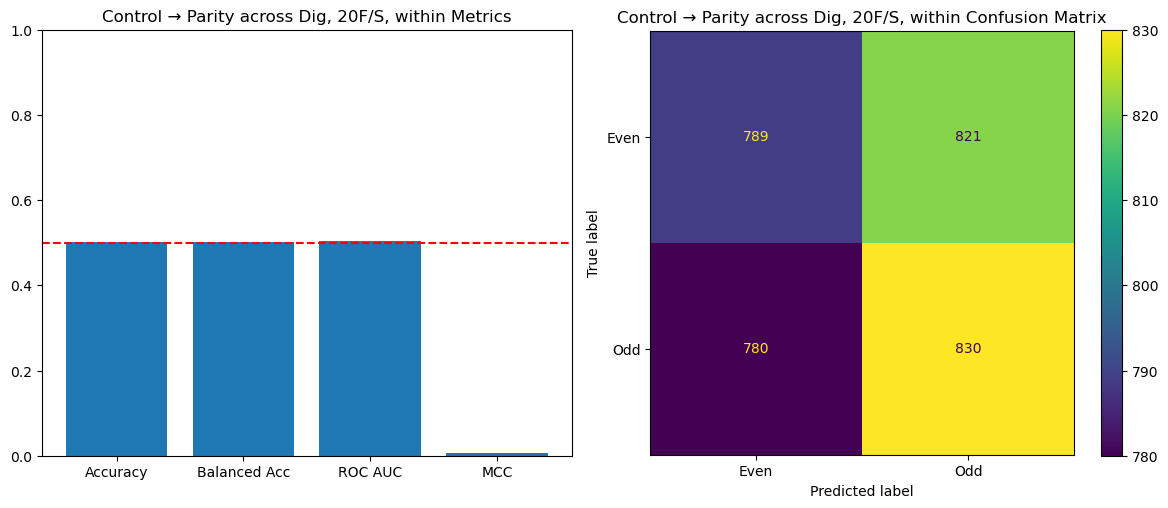

         feature  importance
5       contrast    0.117519
6  dissimilarity    0.102194
7    homogeneity    0.101482
2          alpha    0.100835
8         energy    0.099801


In [186]:
for name, result in [(f'Parity → Control across {modality}, {font}, {mode}', par_c1),
                     (f'Control → Parity across {modality}, {font}, {mode}', c1_par)]:
    if result:
        print(f"\n{name} Performance:")
        print(f"Accuracy: {result['accuracy']:.3f} (Chance: 0.5)")
        print(f"Balanced Accuracy: {result['balanced_accuracy']:.3f}")
        print(f"ROC AUC: {result['roc_auc']:.3f}")
        print(f"Matthews CC: {result['mcc']:.3f}")
        print(f"Support: {result['support']} samples")
        plot_diagnostics(result, name)
        print(result['feature_importances'].head(5))
    else:
        print(f"\n{name}: No data available")